# S2 | Model: Confidence & Calibration

**Session 2** — 1k VQA control question pool.

Analyses model confidence (logprob-based) across conditions (`original`, `blind`, `inst_blind`) and control variant types.


In [8]:
import json
import pandas as pd
import numpy as np
import os
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.vqa import VQAAnswerMapper, vqa_accuracy

RESULTS_DIR = '/home/david/Desktop/yuna/HPA/evaluation/logits/vlm/pretrained'
SEMANTICS_PATH = '/home/david/Desktop/yuna/HPA/dataset/vqa/vqa1k_semantics.jsonl'

CONTROL_TYPES = ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']

COMPLETE_MODELS = [
    'llava-v1.6-vicuna-7b-hf',
    'llava-v1.6-vicuna-13b-hf',
    'Qwen3-VL-2B-Instruct',
    'Qwen3-VL-4B-Instruct',
]

mapper = VQAAnswerMapper()
sem_df = pd.read_json(SEMANTICS_PATH, lines=True)[['question_id', 'ent', 'w', 'op']]

def load_confidence(model, dataset):
    path = f'{RESULTS_DIR}/{model}/{dataset}.jsonl'
    if not os.path.exists(path):
        return []
    rows = []
    with open(path) as f:
        data_list = [json.loads(l) for l in f]
    n = len(data_list)
    if n == 0:
        return []
    status = 'OK' if n == 1000 else f'WARNING: {n}/1000'
    print(f'  [{status}] {model} | {dataset}')

    for ex in data_list:
        if 'generated_logits' not in ex:
            continue
        answers = ex.get('generated_answers') or {}
        gt = mapper.get_answers(ex['question_id'])
        for ct, logit_data in ex['generated_logits'].items():
            if ct not in CONTROL_TYPES:
                continue
            output = answers.get(ct, '')
            if output == '':
                continue
            token_probs = np.exp([t['logprob'] for t in logit_data['content']])
            rows.append({
                'model': model,
                'dataset': dataset,
                'question_id': ex['question_id'],
                'question_text': ex.get(ct, ''),
                'control_type': ct,
                'output': output,
                'confidence': float(token_probs.mean()),
                'accuracy': vqa_accuracy(output, gt) if gt else None,
            })
    return rows

# All three conditions: control (with image), blind (no image), inst_blind (no image + instruction)
datasets = ['vqa_1k_control', 'vqa_1k_control_blind', 'vqa_1k_control_inst_blind']
all_rows = []
for model in COMPLETE_MODELS:
    for ds in datasets:
        all_rows.extend(load_confidence(model, ds))

df = pd.DataFrame(all_rows)
df['accuracy'] = pd.to_numeric(df['accuracy'], errors='coerce')
df['control_type'] = pd.Categorical(df['control_type'], categories=CONTROL_TYPES, ordered=True)
df = df.merge(sem_df, on='question_id', how='left')

print(f'\nLoaded {len(df):,} rows | {df["model"].nunique()} models | {df["question_id"].nunique()} questions')
print(f'Datasets: {df["dataset"].unique().tolist()}')
print(f'Control types present: {sorted(df["control_type"].dropna().unique())}')

  [OK] llava-v1.6-vicuna-7b-hf | vqa_1k_control
   Loading VQA annotations from /home/david/Desktop/yuna/data/v2_mscoco_val2014_annotations.json...
   ✓ Loaded 214354 VQA annotations
  [OK] llava-v1.6-vicuna-7b-hf | vqa_1k_control_blind
  [OK] llava-v1.6-vicuna-7b-hf | vqa_1k_control_inst_blind
  [OK] llava-v1.6-vicuna-13b-hf | vqa_1k_control
  [OK] llava-v1.6-vicuna-13b-hf | vqa_1k_control_blind
  [OK] llava-v1.6-vicuna-13b-hf | vqa_1k_control_inst_blind
  [OK] Qwen3-VL-2B-Instruct | vqa_1k_control
  [OK] Qwen3-VL-2B-Instruct | vqa_1k_control_blind
  [OK] Qwen3-VL-2B-Instruct | vqa_1k_control_inst_blind
  [OK] Qwen3-VL-4B-Instruct | vqa_1k_control
  [OK] Qwen3-VL-4B-Instruct | vqa_1k_control_blind
  [OK] Qwen3-VL-4B-Instruct | vqa_1k_control_inst_blind

Loaded 59,996 rows | 4 models | 1000 questions
Datasets: ['vqa_1k_control', 'vqa_1k_control_blind', 'vqa_1k_control_inst_blind']
Control types present: ['deictic_removed', 'object_removed', 'pronominalized', 'question', 'weaker_object'

In [9]:
# Sanity-check: pivot a few questions to compare control types side by side
df[['model', 'question_id', 'control_type', 'dataset', 'output', 'confidence', 'accuracy']]\
    .pivot_table(
        index=['question_id', 'control_type'],
        columns=['dataset'],
        values=['output', 'confidence'],
        aggfunc=lambda x: ' | '.join(x.astype(str))
    ).reindex(CONTROL_TYPES, level='control_type').dropna(axis=0).head(20)

confidence  \
dataset                                                         vqa_1k_control   
question_id control_type                                                         
589013      question         0.8266035858047291 | 0.8639899511733848 | 0.97...   
            deictic_removed  0.8266035858047291 | 0.8639899511733848 | 0.97...   
            object_removed   0.8266035858047291 | 0.8639899511733848 | 0.97...   
            weaker_object    0.8266035858047291 | 0.8639899511733848 | 0.97...   
            pronominalized   0.8266035858047291 | 0.8639899511733848 | 0.97...   
757004      question         0.8111396759313092 | 0.7790435272673468 | 0.83...   
            deictic_removed  0.7962360650387396 | 0.7905193895630517 | 0.88...   
            object_removed   0.8165766962048836 | 0.8147381786294834 | 0.74...   
            weaker_object    0.7829142528954549 | 0.782855433567096 | 0.809...   
            pronominalized   0.8237992092516777 | 0.7809535678713657 | 0.87...   
1342072     question         0.5648321404039972 | 0.6408221039002799 | 0.69...   
            deictic_removed  0.5648321404039972 | 0.6408221039002799 | 0.69...   
            object_removed   0.5395322246029775 | 0.5953619330384412 | 0.80...   
            weaker_object    0.546300285554474 | 0.588489688285578 | 0.7267...   
            pronominalized   0.5763913742997047 | 0.6877528539310338 | 0.50...   
2006001     question         0.918366896180033 | 0.8608671559019703 | 0.742...   
            deictic_removed  0.918366896180033 | 0.8608671559019703 | 0.742...   
            object_removed   0.8713711913183547 | 0.8489140314288228 | 0.89...   
            weaker_object    0.9130442650863603 | 0.8759138331807469 | 0.74...   
            pronominalized   0.9007882160279248 | 0.8613721412107759 | 0.76...   

                                                                                \
dataset                                                   vqa_1k_control_blind   
question_id control_type                                                         
589013      question         0.8647422461380605 | 0.7939964344102005 | 0.77...   
            deictic_removed  0.8647422461380605 | 0.7939964344102005 | 0.77...   
            object_removed   0.8647422461380605 | 0.7939964344102005 | 0.77...   
            weaker_object    0.8647422461380605 | 0.7939964344102005 | 0.77...   
            pronominalized   0.8647422461380605 | 0.7939964344102005 | 0.77...   
757004      question         0.8607484746049576 | 0.8575011333202238 | 0.95...   
            deictic_removed  0.8787046666474478 | 0.9266670460027308 | 0.71...   
            object_removed   0.7999695637040329 | 0.8393712465178058 | 0.80...   
            weaker_object    0.8511101659312197 | 0.8605685276221601 | 0.85...   
            pronominalized   0.7904984402292277 | 0.8393645769714007 | 0.90...   
1342072     question         0.5019002298592962 | 0.6766485129379349 | 0.46...   
            deictic_removed  0.5019002298592962 | 0.6766485129379349 | 0.46...   
            object_removed   0.6376544713439968 | 0.5735930060122605 | 0.55...   
            weaker_object    0.4819310825100964 | 0.5325882791757757 | 0.50...   
            pronominalized   0.5706787209619274 | 0.6151879323222371 | 0.81...   
2006001     question         0.7358773643683756 | 0.8785109984179171 | 0.68...   
            deictic_removed  0.7358773643683756 | 0.8785109984179171 | 0.68...   
            object_removed   0.697880729530301 | 0.8964548999452719 | 0.802...   
            weaker_object    0.779759339641968 | 0.9092499289489411 | 0.475...   
            pronominalized   0.8074365702867183 | 0.9179426814806598 | 0.77...   

                                                                                \
dataset                                              vqa_1k_control_inst_blind   
question_id control_type                                                         
589013      question         0.9352252993275836 

In [10]:
# Data already scored and merged in setup cell — quick sanity check
print(f"Rows: {len(df):,}  |  Models: {df['model'].nunique()}  |  Questions: {df['question_id'].nunique()}")
print(f"Control types: {list(df['control_type'].cat.categories)}")
df[['model', 'dataset', 'control_type', 'output', 'confidence', 'accuracy', 'ent']].head(10)

Rows: 59,996  |  Models: 4  |  Questions: 1000
Control types: ['question', 'deictic_removed', 'object_removed', 'weaker_object', 'pronominalized']


,model,dataset,control_type,output,confidence,accuracy,ent
0,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,1,0.974205,1.0,object
1,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,1,0.974560,1.0,object
2,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,1,0.846013,1.0,object
3,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,1,0.900691,1.0,object
4,llava-v1.6-vicuna-7b-hf,vqa_1k_control,pronominalized,1,0.753529,1.0,object
5,llava-v1.6-vicuna-7b-hf,vqa_1k_control,question,On building,0.656381,1.0,object
6,llava-v1.6-vicuna-7b-hf,vqa_1k_control,deictic_removed,On building,0.656381,1.0,object
7,llava-v1.6-vicuna-7b-hf,vqa_1k_control,object_removed,Street,0.645027,0.0,object
8,llava-v1.6-vicuna-7b-hf,vqa_1k_control,weaker_object,Wall,0.739510,0.0,object
9,llava-v1.6-vicuna-7b-hf,vqa_1k_control,pronominalized,Street,0.688975,0.0,object


In [11]:
control_type_order = CONTROL_TYPES

summary = (
    df.groupby(['model', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
summary['accuracy'] = (summary['accuracy'] * 100).round(1)
summary['confidence'] = (summary['confidence'] * 100).round(1)
summary['control_type'] = pd.Categorical(summary['control_type'], categories=control_type_order, ordered=True)
summary = summary.sort_values(['model', 'dataset', 'control_type'])

summary.pivot_table(
    index=['model', 'control_type'],
    columns='dataset',
    values=['accuracy', 'confidence'],
).round(1)

accuracy                       \
dataset                                  vqa_1k_control vqa_1k_control_blind   
model                    control_type                                          
Qwen3-VL-2B-Instruct     question                  80.8                 35.7   
                         deictic_removed           80.7                 35.2   
                         object_removed            69.3                 32.2   
                         weaker_object             74.8                 32.6   
                         pronominalized            67.3                 31.5   
Qwen3-VL-4B-Instruct     question                  81.9                 34.5   
                         deictic_removed           81.5                 34.6   
                         object_removed            72.4                 31.2   
                         weaker_object             75.7                 31.7   
                         pronominalized            70.0                 31.7   
llava-v1.6-vicuna-13b-hf question                  82.9                 34.1   
                         deictic_removed           82.4                 34.0   
                         object_removed            71.6                 32.4   
                         weaker_object             76.0                 33.0   
                         pronominalized            70.2                 31.8   
llava-v1.6-vicuna-7b-hf  question                  81.7                 34.4   
                         deictic_removed           81.5                 34.1   
                         object_removed            71.4                 33.4   
                         weaker_object             75.1                 32.3   
                         pronominalized            68.4                 32.7   

                                                                    \
dataset                                  vqa_1k_control_inst_blind   
model                    control_type                                
Qwen3-VL-2B-Instruct     question                             35.8   
                         deictic_removed                      35.4   
                         object_removed                       32.6   
                         weaker_object                        33.4   
                         pronominalized                       31.3   
Qwen3-VL-4B-Instruct     question                             37.2   
                         deictic_removed                      37.3   
                         object_removed                       31.8   
                         weaker_object                        33.0   
                         pronominalized                       32.1   
llava-v1.6-vicuna-13b-hf question                             36.3   
                         deictic_removed                      36.4   
                         object_removed                       34.3   
                         weaker_object                        33.5   
                         pronominalized                       31.9   
llava-v1.6-vicuna-7b-hf  question                             33.9   
                         deictic_removed                      33.9   
                         object_removed                       33.0   
                         weaker_object                        32.2   
                         pronominalized                       31.9   

                                             confidence                       \
dataset                                  vqa_1k_control vqa_1k_control_blind   
model                    control_type                                          
Qwen3-VL-2B-Instruct     question                  89.2                 79.9   
                         deictic_removed           89.1                 79.9   
                         object_removed            88.1                 80.9   
                         weaker_object             88.7                 79.0   
                         pronominal

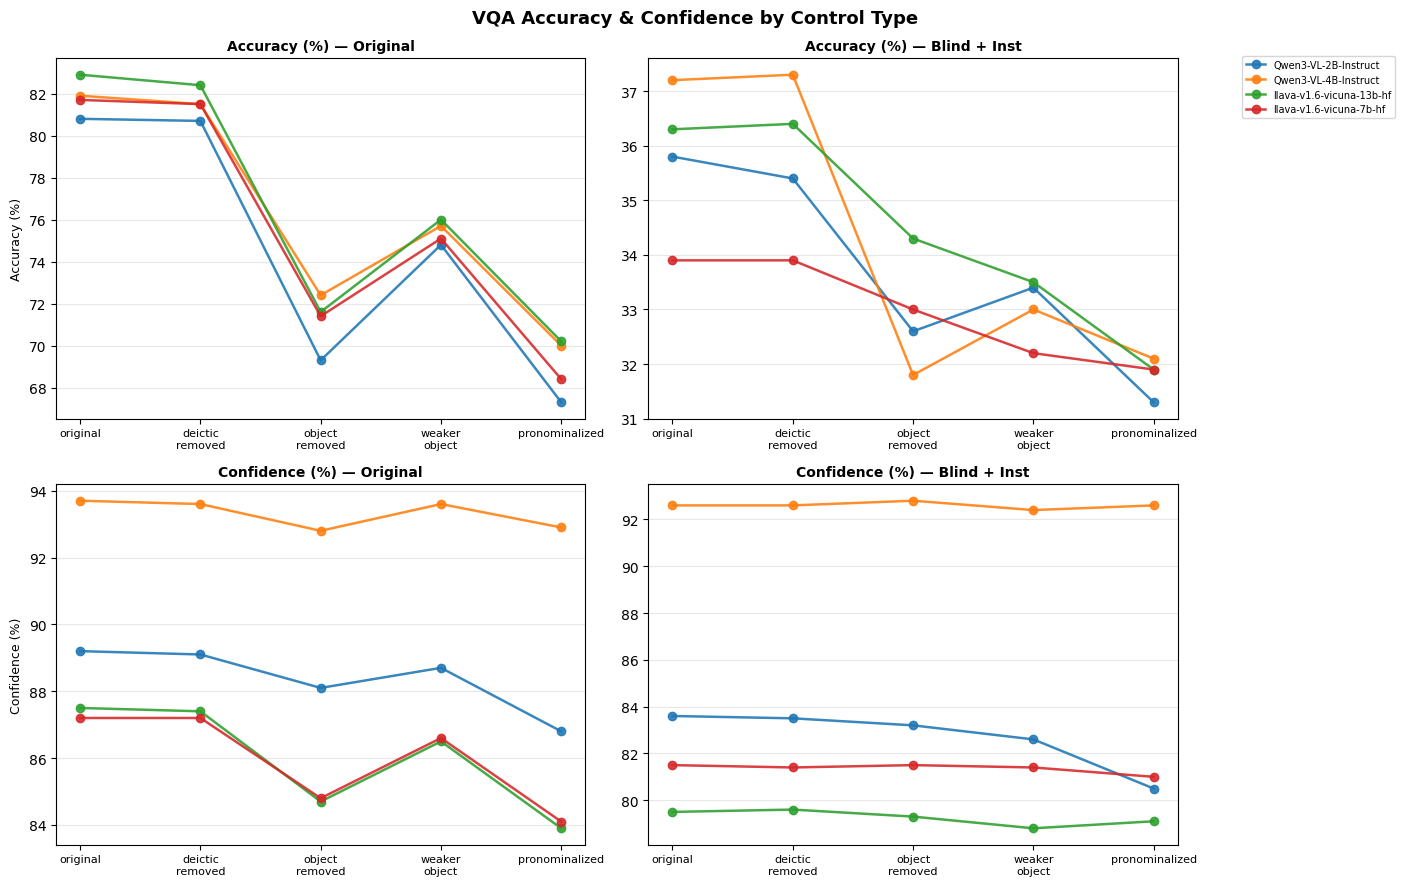

In [12]:
import matplotlib.pyplot as plt

datasets = ['vqa_1k_control', 'vqa_1k_control_inst_blind']
ds_labels = {'vqa_1k_control': 'Original', 'vqa_1k_control_inst_blind': 'Blind + Inst'}
ct_labels = ['original', 'deictic\nremoved', 'object\nremoved', 'weaker\nobject', 'pronominalized']
models_list = sorted(summary['model'].unique())
model_colors = {m: plt.cm.tab10(i) for i, m in enumerate(models_list)}
x = range(len(control_type_order))

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for model in models_list:
            sub = summary[(summary['model'] == model) & (summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            ax.plot(x, sub[metric].values,
                    color=model_colors[model], marker='o', linewidth=1.8,
                    label=model, alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

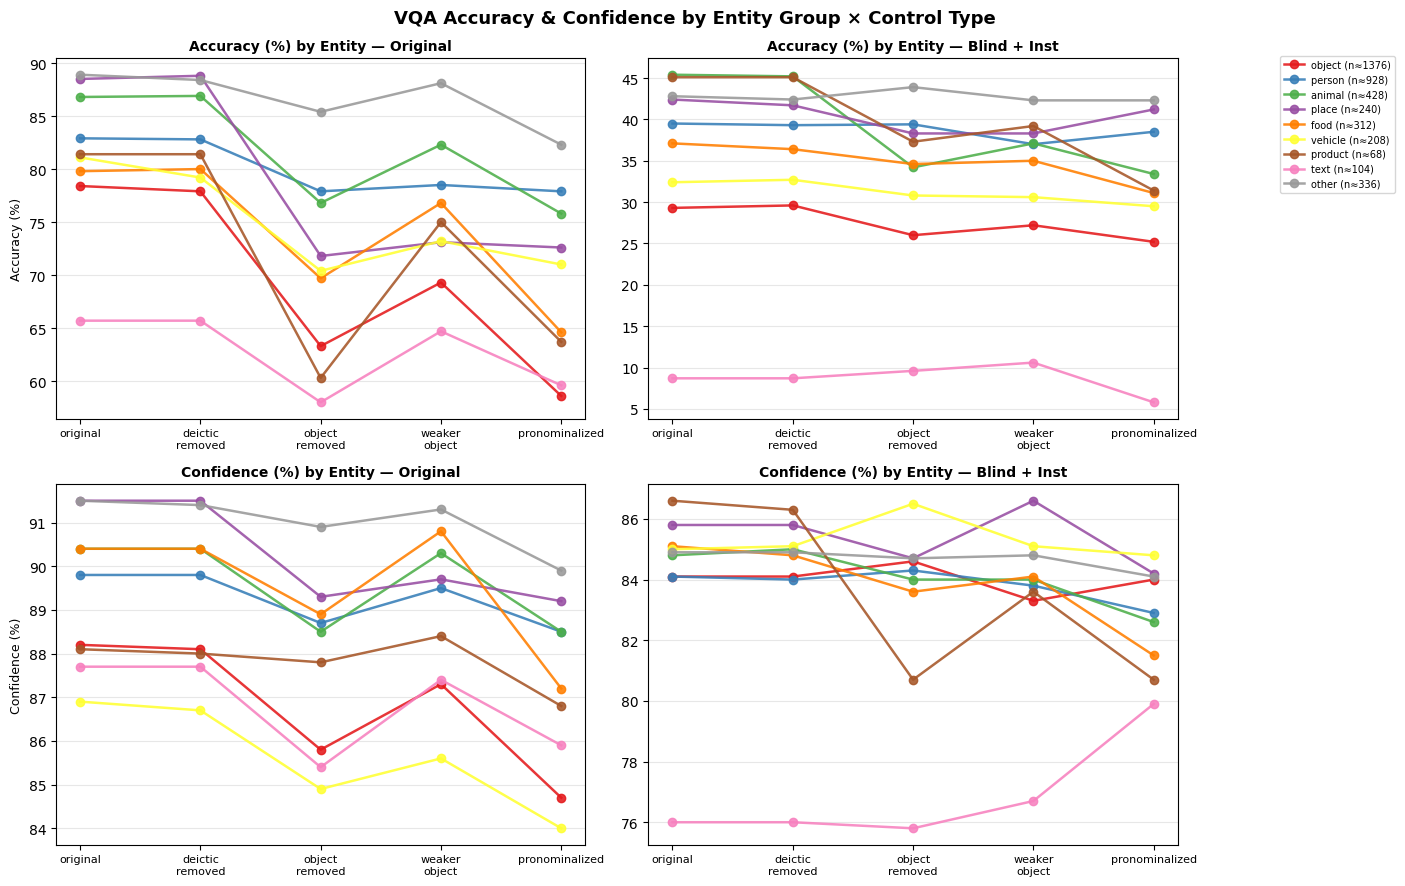

In [13]:
# Entity group analysis: accuracy and confidence across control types
ENT_ORDER = ['object', 'person', 'animal', 'place', 'food', 'vehicle', 'product', 'text', 'other']

ent_summary = (
    df[df['ent'].notna()]
    .groupby(['ent', 'dataset', 'control_type'])
    .agg(accuracy=('accuracy', 'mean'), confidence=('confidence', 'mean'), n=('accuracy', 'count'))
    .reset_index()
)
ent_summary['accuracy'] = (ent_summary['accuracy'] * 100).round(1)
ent_summary['confidence'] = (ent_summary['confidence'] * 100).round(1)
ent_summary['control_type'] = pd.Categorical(
    ent_summary['control_type'], categories=control_type_order, ordered=True
)

ent_colors = {e: plt.cm.Set1(i / len(ENT_ORDER)) for i, e in enumerate(ENT_ORDER)}

fig, axes = plt.subplots(2, 2, figsize=(14, 9)) # , sharey='row')

for row_i, metric in enumerate(['accuracy', 'confidence']):
    ylabel = 'Accuracy (%)' if metric == 'accuracy' else 'Confidence (%)'
    for col_i, ds in enumerate(datasets):
        ax = axes[row_i][col_i]
        for ent in ENT_ORDER:
            sub = ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]
            if sub.empty or sub[metric].isna().all():
                continue
            sub = sub.set_index('control_type').reindex(control_type_order)
            n_mean = int(ent_summary[(ent_summary['ent'] == ent) & (ent_summary['dataset'] == ds)]['n'].mean())
            ax.plot(x, sub[metric].values,
                    color=ent_colors[ent], marker='o', linewidth=1.8,
                    label=f'{ent} (n≈{n_mean})', alpha=0.88)
        ax.set_xticks(list(x))
        ax.set_xticklabels(ct_labels, fontsize=8)
        ax.set_title(f'{ylabel} by Entity — {ds_labels[ds]}', fontsize=10, fontweight='bold')
        ax.grid(axis='y', alpha=0.3)
        if col_i == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_i == 0 and col_i == 1:
            ax.legend(fontsize=7, loc='upper right', bbox_to_anchor=(1.42, 1.02))

plt.suptitle('VQA Accuracy & Confidence by Entity Group × Control Type', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Clean confidence KDE — token probability only, no accuracy mixed in

The existing plots used the x-axis label "Mean token probability / accuracy", overlaying
model token probability and human accuracy on the same axis as if they're comparable.
They're not: confidence = P(output token | context), accuracy = correctness w.r.t. GT.

Here we load the full model set from raw logits and plot **only token probability** per condition.

In [ ]:
import json, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.insert(0, '/home/david/Desktop/yuna/HPA/analysis')
from utils.constants import GROUP_COLORS, GROUP_ORDER

LOGITS_ROOT = '/home/david/Desktop/yuna/HPA/evaluation/logits'

MODEL_MAP = {
    ('vlm',           'Qwen3-VL-8B-Instruct'):      ('Qwen3-VL-8B',         'VLM'),
    ('vlm',           'Qwen3-VL-32B-Instruct'):     ('Qwen3-VL-32B',        'VLM'),
    ('vlm',           'Qwen3-VL-4B-Instruct'):      ('Qwen3-VL-4B',         'VLM'),
    ('vlm',           'Qwen3-VL-2B-Instruct'):      ('Qwen3-VL-2B',         'VLM'),
    ('vlm',           'InternVL3_5-1B'):             ('InternVL-1B',         'VLM'),
    ('vlm',           'InternVL3_5-2B'):             ('InternVL-2B',         'VLM'),
    ('vlm',           'InternVL3_5-8B'):             ('InternVL-8B',         'VLM'),
    ('vlm',           'llava-1.5-7b-hf'):            ('LLaVA-1.5-7B',       'VLM'),
    ('vlm',           'llava-v1.6-mistral-7b-hf'):   ('LLaVA-Mistral',      'VLM'),
    ('vlm',           'llava-v1.6-vicuna-7b-hf'):    ('LLaVA-Vicuna',       'VLM'),
    ('lm_decoder',    'llava-1.5-7b-hf'):            ('LLaVA-1.5 (LM)',     'VLM backbone decoder'),
    ('lm_decoder',    'llava-v1.6-mistral-7b-hf'):   ('LLaVA-Mistral (LM)', 'VLM backbone decoder'),
    ('lm_decoder',    'llava-v1.6-vicuna-7b-hf'):    ('LLaVA-Vicuna (LM)',  'VLM backbone decoder'),
    ('backbone',      'Qwen3-0.6B'):                 ('Qwen3-0.6B',         'standalone LLM'),
    ('backbone',      'Qwen3-1.7B'):                 ('Qwen3-1.7B',         'standalone LLM'),
    ('backbone',      'Qwen3-4B'):                   ('Qwen3-4B',           'standalone LLM'),
    ('backbone',      'Qwen3-8B'):                   ('Qwen3-8B',           'standalone LLM'),
    ('backbone',      'Qwen3-32B'):                  ('Qwen3-32B',          'standalone LLM'),
    ('backbone',      'Mistral-7B-Instruct-v0.2'):   ('Mistral-7B',         'standalone LLM'),
    ('backbone',      'vicuna-13b-v1.5'):             ('Vicuna-13B',         'standalone LLM'),
    ('backbone_think','Qwen3-0.6B'):                  ('Qwen3-0.6B (think)', 'standalone LLM (think)'),
    ('backbone_think','Qwen3-1.7B'):                  ('Qwen3-1.7B (think)', 'standalone LLM (think)'),
    ('backbone_think','Qwen3-4B'):                    ('Qwen3-4B (think)',   'standalone LLM (think)'),
    ('backbone_think','Qwen3-8B'):                    ('Qwen3-8B (think)',   'standalone LLM (think)'),
    ('backbone_think','Qwen3-32B'):                   ('Qwen3-32B (think)',  'standalone LLM (think)'),
}

CONDITION_FILES = {
    'blind':      'vqa_1k_control_blind.jsonl',
    'inst_blind': 'vqa_1k_control_inst_blind.jsonl',
}

EOS_TOKENS = {'<|im_end|>', '</s>', '<eos>', '<|endoftext|>', '<|end|>'}

def extract_confidence(path):
    """Returns list of (question_id, mean_token_probability) for variant C ('question' ctrl type)."""
    rows = []
    n_bad = 0
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                ex = json.loads(line)
            except json.JSONDecodeError:
                n_bad += 1
                continue
            logits = ex.get('generated_logits', {})
            if not logits:
                continue
            entry = logits.get('question') or next(iter(logits.values()), None)
            if entry is None:
                continue
            probs = [np.exp(t['logprob']) for t in entry['content']
                     if t['token'] not in EOS_TOKENS]
            if probs:
                rows.append({'question_id': ex['question_id'], 'confidence': float(np.mean(probs))})
    if n_bad:
        print(f'  [warn] {n_bad} malformed lines in {os.path.basename(path)}')
    return rows

conf_rows = []
for (mtype, mdir), (display, group) in MODEL_MAP.items():
    for cond, fname in CONDITION_FILES.items():
        path = f'{LOGITS_ROOT}/{mtype}/pretrained/{mdir}/{fname}'
        if not os.path.exists(path):
            continue
        for r in extract_confidence(path):
            conf_rows.append({**r, 'model': display, 'model_group': group, 'condition': cond})

conf_df = pd.DataFrame(conf_rows)
print(f'Loaded {len(conf_df):,} rows | {conf_df["model"].nunique()} models | {conf_df["question_id"].nunique()} questions')
print(conf_df.groupby(['model_group', 'condition'])['confidence'].agg(['mean','count']).round(3))

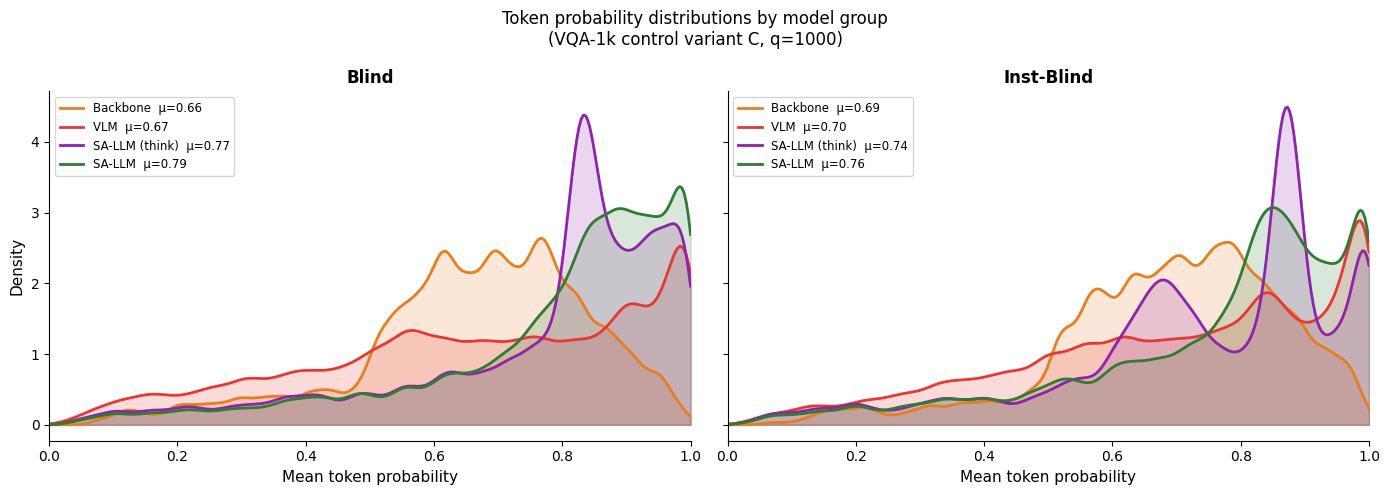

In [15]:
from scipy.stats import gaussian_kde

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
CONDITIONS = ['blind', 'inst_blind']
COND_LABELS = {'blind': 'Blind', 'inst_blind': 'Inst-Blind'}
x_grid = np.linspace(0, 1, 300)

for ax, cond in zip(axes, CONDITIONS):
    sub = conf_df[conf_df['condition'] == cond]
    for grp in GROUP_ORDER:
        grp_data = sub[sub['model_group'] == grp]['confidence'].dropna().values
        if len(grp_data) < 10:
            continue
        kde = gaussian_kde(grp_data, bw_method=0.08)
        y = kde(x_grid)
        color = GROUP_COLORS.get(grp, '#888')
        label = grp.replace('standalone LLM', 'SA-LLM').replace('VLM backbone decoder', 'Backbone')
        ax.fill_between(x_grid, y, alpha=0.18, color=color)
        ax.plot(x_grid, y, color=color, lw=2, label=f'{label}  μ={grp_data.mean():.2f}')

    ax.set_xlabel('Mean token probability', fontsize=11)
    ax.set_title(f'{COND_LABELS[cond]}', fontsize=12, fontweight='bold')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8.5, frameon=True, loc='upper left')
    ax.set_xlim(0, 1)

axes[0].set_ylabel('Density', fontsize=11)
fig.suptitle('Token probability distributions by model group\n(VQA-1k control variant C, q=1000)',
             fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
## Per-question scatter: model confidence vs human accuracy
#
# The overconfidence claim: models produce high token probability (~0.8-1.0)
# on questions that humans frequently fail. If true, correlation should be near zero —
# confidence is blind to question difficulty.

from pathlib import Path
from scipy import stats
from export_helpers import read_response_exports

ROOT = Path('/home/david/Desktop/yuna/HPA')
exports = read_response_exports(ROOT)

# human_avg_acc per question (variant C, number/text questions used in human study)
human_acc = (exports['model_inst_blind']
             .query("variant == 'C'")
             [['question_id', 'human_avg_acc']]
             .drop_duplicates('question_id'))

# Per-question mean confidence per model group, inst_blind
q_conf = (conf_df[conf_df['condition'] == 'inst_blind']
          .groupby(['question_id', 'model_group'])['confidence']
          .mean()
          .reset_index())

# Join — only questions present in human study
scatter_df = q_conf.merge(human_acc, on='question_id')
print(f'Joined: {len(scatter_df)} rows ({scatter_df["question_id"].nunique()} questions × {scatter_df["model_group"].nunique()} groups)')

# ── Plot ──────────────────────────────────────────────────────────────────────
groups_present = [g for g in GROUP_ORDER if g in scatter_df['model_group'].unique()]
fig, axes = plt.subplots(1, len(groups_present), figsize=(4.5 * len(groups_present), 4.5), sharey=True)
if len(groups_present) == 1:
    axes = [axes]

for ax, grp in zip(axes, groups_present):
    sub = scatter_df[scatter_df['model_group'] == grp]
    x, y = sub['confidence'].values, sub['human_avg_acc'].values
    color = GROUP_COLORS.get(grp, '#888')

    ax.scatter(x, y, alpha=0.45, s=18, color=color, edgecolors='none')

    r, p = stats.pearsonr(x, y)
    m, b = np.polyfit(x, y, 1)
    xr = np.linspace(x.min(), x.max(), 100)
    ax.plot(xr, m * xr + b, color=color, lw=1.8)

    ax.set_xlabel('Mean token probability (inst-blind)', fontsize=10)
    ax.set_title(f'{grp}\nr={r:.2f}, p={p:.3f}', fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.axhline(y.mean(), color='#bbb', lw=0.8, ls='--')

axes[0].set_ylabel('Human accuracy (avg over 40 participants)', fontsize=10)
fig.suptitle('Per-question: model token probability vs human accuracy\n'
             'Low/no correlation = model is equally confident on easy and hard questions',
             fontsize=11)
plt.tight_layout()
plt.show()

# Summary table
print('\nPearson r (model confidence vs human accuracy):')
for grp in groups_present:
    sub = scatter_df[scatter_df['model_group'] == grp]
    r, p = stats.pearsonr(sub['confidence'], sub['human_avg_acc'])
    print(f'  {grp:<30}  r={r:+.3f}  p={p:.4f}')